<a href="https://colab.research.google.com/github/GeorgeT27/Generative-model-DYI/blob/main/Copy_of_Conditional_Flow_Matching_Morpho_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor, Compose, Normalize
from torch.utils.data import DataLoader
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import StepLR
import torch.distributions as distributions
from tqdm import tqdm
import pandas as pd
from copy import deepcopy
import os
import sys
from morphomnist import io

In [3]:
class RectifiedFlow:
  def euler(self,x_t,v,dt):
    x_t=x_t+v*dt
    return x_t
  def create_flow(self,x_1,t):
    x_0=torch.randn_like(x_1)
    t=t[:,None,None,None]
    x_t=t*x_1+(1-t)*x_0
    return x_t,x_0
  def mse_loss(self,x_1,x_0,v):
    loss=F.mse_loss(x_1-x_0,v)
    return loss

In [14]:
# Replace your existing FiLM model with this improved deep version

class ImprovedFiLMLayer(nn.Module):
    """Better FiLM layer with proper initialization and optional bypass"""
    def __init__(self, num_features, condition_dim, use_film=True):
        super().__init__()
        self.use_film = use_film
        
        if use_film:
            self.scale_transform = nn.Linear(condition_dim, num_features)
            self.shift_transform = nn.Linear(condition_dim, num_features)
            
            # Better initialization - start closer to identity
            nn.init.zeros_(self.scale_transform.weight)
            nn.init.zeros_(self.scale_transform.bias)
            nn.init.zeros_(self.shift_transform.weight)
            nn.init.zeros_(self.shift_transform.bias)
    
    def forward(self, x, condition):
        if not self.use_film or condition is None:
            return x
            
        scale = self.scale_transform(condition).unsqueeze(-1).unsqueeze(-1)
        shift = self.shift_transform(condition).unsqueeze(-1).unsqueeze(-1)
        
        # Apply FiLM: x * (1 + scale) + shift (more stable than x * scale + shift)
        return x * (1 + scale) + shift

class DeepResBlockFiLM(nn.Module):
    """Deep residual block with FiLM conditioning"""
    
    def __init__(self, in_channels, out_channels, condition_dim, use_film=True, dropout=0.1):
        super().__init__()
        
        # First conv path
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.norm1 = nn.GroupNorm(min(8, out_channels), out_channels)
        self.film1 = ImprovedFiLMLayer(out_channels, condition_dim, use_film)
        
        # Second conv path
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.norm2 = nn.GroupNorm(min(8, out_channels), out_channels)
        self.film2 = ImprovedFiLMLayer(out_channels, condition_dim, use_film)
        
        # Dropout for regularization
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        
        # Shortcut connection
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        
        self.act = nn.SiLU()  # Better activation than ReLU
    
    def forward(self, x, condition=None):
        residual = self.shortcut(x)
        
        # First conv block
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.film1(h, condition)
        h = self.act(h)
        h = self.dropout(h)
        
        # Second conv block
        h = self.conv2(h)
        h = self.norm2(h)
        h = self.film2(h, condition)
        
        # Residual connection
        return self.act(h + residual)



In [15]:
# IMPROVED: Attention block that can use conditioning information
class ConditionedAttentionBlock(nn.Module):
    """Self-attention block that can optionally incorporate conditioning"""
    def __init__(self, channels, condition_dim=None, use_conditioning=True):
        super().__init__()
        self.channels = channels
        self.use_conditioning = use_conditioning and condition_dim is not None
        
        self.norm = nn.GroupNorm(min(8, channels), channels)
        self.q = nn.Conv2d(channels, channels, 1)
        self.k = nn.Conv2d(channels, channels, 1)
        self.v = nn.Conv2d(channels, channels, 1)
        self.proj_out = nn.Conv2d(channels, channels, 1)
        
        # Add conditioning projection if enabled
        if self.use_conditioning:
            # Project condition to query space for modulation
            self.condition_to_q = nn.Linear(condition_dim, channels)
            self.condition_to_k = nn.Linear(condition_dim, channels)
            
    def forward(self, x, condition=None):
        residual = x
        h_ = self.norm(x)
        
        # Compute Q, K, V
        q = self.q(h_)
        k = self.k(h_)
        v = self.v(h_)
        
        # Apply conditioning if available
        if condition is not None and self.use_conditioning:
            # Get spatial dimensions from queries
            b, channels_out, h, w = q.shape
            
            # Project condition and reshape for spatial broadcasting
            # FIXED: Use channels_out (from q.shape) instead of condition dimension
            q_cond = self.condition_to_q(condition).view(b, channels_out, 1, 1).expand(-1, -1, h, w)
            k_cond = self.condition_to_k(condition).view(b, channels_out, 1, 1).expand(-1, -1, h, w)
            
            q = q + q_cond
            k = k + k_cond
        
        # Compute attention
        b, c, h, w = q.shape
        q = q.reshape(b, c, h * w).transpose(1, 2)
        k = k.reshape(b, c, h * w)
        v = v.reshape(b, c, h * w).transpose(1, 2)
        
        attn = torch.bmm(q, k) * (c ** -0.5)
        attn = F.softmax(attn, dim=-1)
        
        h_ = torch.bmm(attn, v).transpose(1, 2).reshape(b, c, h, w)
        h_ = self.proj_out(h_)
        
        return residual + h_

In [16]:
# FIXED: U-Net with proper attention conditioning
class ImprovedDeepMiniUnetFiLM(nn.Module):
    """Deep U-Net with PROPER attention conditioning"""
    
    def __init__(self, base_channels=64, condition_dim=128, use_morphometrics=False, 
                 num_res_blocks=2, use_attention=True, dropout=0.1):
        super().__init__()
        
        self.condition_dim = condition_dim
        self.base_channels = base_channels
        self.use_morphometrics = use_morphometrics
        self.use_attention = use_attention
        
        # Time embedding
        self.time_embed = nn.Sequential(
            nn.Linear(base_channels, condition_dim),
            nn.SiLU(),
            nn.Linear(condition_dim, condition_dim),
        )
        
        # Label embedding
        self.label_embed = nn.Embedding(11, condition_dim)
        
        # Morphometric embedding
        if use_morphometrics:
            self.morpho_net = nn.Sequential(
                nn.Linear(4, condition_dim // 2),
                nn.SiLU(),
                nn.Linear(condition_dim // 2, condition_dim),
                nn.SiLU(),
                nn.Linear(condition_dim, condition_dim)
            )
        
        # Input layer
        self.conv_in = nn.Conv2d(1, base_channels, 3, padding=1)
        
        # Channel progression
        ch = [base_channels, base_channels*2, base_channels*4, base_channels*8]
        
        # Build encoder blocks with PROPER attention conditioning
        self.down_blocks = nn.ModuleList()
        for level, (in_ch, out_ch) in enumerate([(ch[0], ch[1]), (ch[1], ch[2]), (ch[2], ch[3])]):
            level_blocks = nn.ModuleList()
            
            # Add ResNet blocks
            for i in range(num_res_blocks):
                input_ch = in_ch if i == 0 else out_ch
                level_blocks.append(DeepResBlockFiLM(input_ch, out_ch, condition_dim, True, dropout))
            
            # Add conditioned attention block
            if use_attention:
                level_blocks.append(ConditionedAttentionBlock(out_ch, condition_dim, True))
            
            self.down_blocks.append(level_blocks)
        
        # Downsampling
        self.down1 = nn.Conv2d(ch[1], ch[1], 3, stride=2, padding=1)
        self.down2 = nn.Conv2d(ch[2], ch[2], 3, stride=2, padding=1)
        
        # Middle blocks with conditioning
        self.middle_blocks = nn.ModuleList([
            DeepResBlockFiLM(ch[3], ch[3], condition_dim, True, dropout),
            DeepResBlockFiLM(ch[3], ch[3], condition_dim, True, dropout),
        ])
        
        if use_attention:
            self.middle_attention = ConditionedAttentionBlock(ch[3], condition_dim, True)
        else:
            self.middle_attention = None
        
        # Decoder blocks
        self.up1 = nn.ConvTranspose2d(ch[3], ch[2], 4, stride=2, padding=1)
        self.up2 = nn.ConvTranspose2d(ch[2], ch[1], 4, stride=2, padding=1)
        
        self.up_blocks = nn.ModuleList()
        # Up level 1: 512 -> 256
        up1_blocks = nn.ModuleList()
        for i in range(num_res_blocks):
            in_ch = ch[2] * 2 if i == 0 else ch[2]
            up1_blocks.append(DeepResBlockFiLM(in_ch, ch[2], condition_dim, True, dropout))
        if use_attention:
            up1_blocks.append(ConditionedAttentionBlock(ch[2], condition_dim, True))
        self.up_blocks.append(up1_blocks)
        
        # Up level 2: 256 -> 128
        up2_blocks = nn.ModuleList()
        for i in range(num_res_blocks):
            in_ch = ch[1] * 2 if i == 0 else ch[1]
            up2_blocks.append(DeepResBlockFiLM(in_ch, ch[1], condition_dim, True, dropout))
        if use_attention:
            up2_blocks.append(ConditionedAttentionBlock(ch[1], condition_dim, True))
        self.up_blocks.append(up2_blocks)
        
        # Final blocks
        self.final_blocks = nn.ModuleList()
        for i in range(num_res_blocks):
            in_ch = ch[0] + ch[1] if i == 0 else ch[0]
            self.final_blocks.append(DeepResBlockFiLM(in_ch, ch[0], condition_dim, True, dropout))
        
        # Output
        self.norm_out = nn.GroupNorm(min(8, base_channels), base_channels)
        self.conv_out = nn.Conv2d(base_channels, 1, 3, padding=1)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Linear):
            nn.init.kaiming_normal_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
    
    def get_time_embedding(self, t):
        half_dim = self.base_channels // 2
        emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return self.time_embed(emb)
    
    def forward(self, x, t, y=None, morpho=None):
        # Build conditioning vector
        condition = self.get_time_embedding(t)
        
        if y is not None:
            y_mapped = torch.where(y == -1, torch.tensor(10, device=y.device, dtype=y.dtype), y)
            label_emb = self.label_embed(y_mapped)
            condition = condition + label_emb
        
        if morpho is not None and self.use_morphometrics:
            area_norm = (morpho['area'] - 112.79) / 84.32
            thickness_norm = (morpho['thickness'] - 3.13) / 1.98
            width_norm = (morpho['width'] - 13.0) / 4.0
            height_norm = (morpho['height'] - 19.0) / 2.0
            
            morpho_vec = torch.stack([
                torch.clamp(area_norm, -3, 3),
                torch.clamp(thickness_norm, -3, 3),
                torch.clamp(height_norm, -3, 3),
                torch.clamp(width_norm, -3, 3)
            ], dim=-1)
            
            morpho_emb = self.morpho_net(morpho_vec)
            condition = condition + morpho_emb
        
        # Forward pass with PROPER conditioning for ALL blocks
        h = self.conv_in(x)
        skips = [h]
        
        # Encoder - ALL blocks get conditioning
        for level, blocks in enumerate(self.down_blocks):
            for block in blocks:
                h = block(h, condition)  # ✅ EVERY block gets conditioning!
            skips.append(h)
            
            # Apply downsampling
            if level == 0:
                h = self.down1(h)
            elif level == 1:
                h = self.down2(h)
        
        # Middle - with conditioning
        for block in self.middle_blocks:
            h = block(h, condition)
        
        if self.middle_attention is not None:
            h = self.middle_attention(h, condition)  # ✅ Attention gets conditioning!
        
        # Decoder - ALL blocks get conditioning
        h = self.up1(h)
        h = torch.cat([h, skips[2]], dim=1)
        for block in self.up_blocks[0]:
            h = block(h, condition)  # ✅ EVERY block gets conditioning!
        
        h = self.up2(h)
        h = torch.cat([h, skips[1]], dim=1)
        for block in self.up_blocks[1]:
            h = block(h, condition)  # ✅ EVERY block gets conditioning!
        
        h = torch.cat([h, skips[0]], dim=1)
        for block in self.final_blocks:
            h = block(h, condition)
        
        h = self.norm_out(h)
        h = F.silu(h)
        return self.conv_out(h)

In [29]:
# IMPROVED: U-Net with CONCATENATED conditioning (instead of additive)
class ConcatenatedConditioningUnetFiLM(nn.Module):
    """Deep U-Net with CONCATENATED conditioning for better performance"""
    
    def __init__(self, base_channels=64, time_dim=64, label_dim=64, morpho_dim=64, 
                 use_morphometrics=False, num_res_blocks=2, use_attention=True, dropout=0.1):
        super().__init__()
        
        self.base_channels = base_channels
        self.time_dim = time_dim
        self.label_dim = label_dim
        self.morpho_dim = morpho_dim
        self.use_morphometrics = use_morphometrics
        self.use_attention = use_attention
        
        # Calculate total condition dimension
        self.condition_dim = time_dim
        if use_morphometrics:
            self.condition_dim += label_dim + morpho_dim  # Concatenate all
        else:
            self.condition_dim += label_dim  # Just time + label
        
        print(f"Total conditioning dimension: {self.condition_dim}")
        
        # Time embedding
        self.time_embed = nn.Sequential(
            nn.Linear(base_channels, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        
        # Label embedding  
        self.label_embed = nn.Embedding(11, label_dim)
        
        # Morphometric embedding
        if use_morphometrics:
            self.morpho_net = nn.Sequential(
                nn.Linear(4, morpho_dim // 2),
                nn.SiLU(),
                nn.Linear(morpho_dim // 2, morpho_dim),
                nn.SiLU(),
                nn.Linear(morpho_dim, morpho_dim)
            )
        
        # Input layer
        self.conv_in = nn.Conv2d(1, base_channels, 3, padding=1)
        
        # Channel progression
        ch = [base_channels, base_channels*2, base_channels*4, base_channels*8]
        
        # Build encoder blocks with concatenated conditioning
        self.down_blocks = nn.ModuleList()
        for level, (in_ch, out_ch) in enumerate([(ch[0], ch[1]), (ch[1], ch[2]), (ch[2], ch[3])]):
            level_blocks = nn.ModuleList()
            
            # Add ResNet blocks
            for i in range(num_res_blocks):
                input_ch = in_ch if i == 0 else out_ch
                level_blocks.append(DeepResBlockFiLM(input_ch, out_ch, self.condition_dim, True, dropout))
            
            # Add conditioned attention block
            if use_attention:
                level_blocks.append(ConditionedAttentionBlock(out_ch, self.condition_dim, True))
            
            self.down_blocks.append(level_blocks)
        
        # Downsampling
        self.down1 = nn.Conv2d(ch[1], ch[1], 3, stride=2, padding=1)
        self.down2 = nn.Conv2d(ch[2], ch[2], 3, stride=2, padding=1)
        
        # Middle blocks with conditioning
        self.middle_blocks = nn.ModuleList([
            DeepResBlockFiLM(ch[3], ch[3], self.condition_dim, True, dropout),
            DeepResBlockFiLM(ch[3], ch[3], self.condition_dim, True, dropout),
        ])
        
        if use_attention:
            self.middle_attention = ConditionedAttentionBlock(ch[3], self.condition_dim, True)
        else:
            self.middle_attention = None
        
        # Decoder blocks
        self.up1 = nn.ConvTranspose2d(ch[3], ch[2], 4, stride=2, padding=1)
        self.up2 = nn.ConvTranspose2d(ch[2], ch[1], 4, stride=2, padding=1)
        
        self.up_blocks = nn.ModuleList()
        # Up level 1
        up1_blocks = nn.ModuleList()
        for i in range(num_res_blocks):
            in_ch = ch[2] * 2 if i == 0 else ch[2]
            up1_blocks.append(DeepResBlockFiLM(in_ch, ch[2], self.condition_dim, True, dropout))
        if use_attention:
            up1_blocks.append(ConditionedAttentionBlock(ch[2], self.condition_dim, True))
        self.up_blocks.append(up1_blocks)
        
        # Up level 2
        up2_blocks = nn.ModuleList()
        for i in range(num_res_blocks):
            in_ch = ch[1] * 2 if i == 0 else ch[1]
            up2_blocks.append(DeepResBlockFiLM(in_ch, ch[1], self.condition_dim, True, dropout))
        if use_attention:
            up2_blocks.append(ConditionedAttentionBlock(ch[1], self.condition_dim, True))
        self.up_blocks.append(up2_blocks)
        
        # Final blocks
        self.final_blocks = nn.ModuleList()
        for i in range(num_res_blocks):
            in_ch = ch[0] + ch[1] if i == 0 else ch[0]
            self.final_blocks.append(DeepResBlockFiLM(in_ch, ch[0], self.condition_dim, True, dropout))
        
        # Output
        self.norm_out = nn.GroupNorm(min(8, base_channels), base_channels)
        self.conv_out = nn.Conv2d(base_channels, 1, 3, padding=1)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Linear):
            nn.init.kaiming_normal_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
    
    def get_time_embedding(self, t):
        half_dim = self.base_channels // 2
        emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return self.time_embed(emb)
    
    def forward(self, x, t, y=None, morpho=None):
        # Build conditioning vector by CONCATENATION
        conditions = []
        
        # Always include time
        time_emb = self.get_time_embedding(t)
        conditions.append(time_emb)
        
        # Add label conditioning
        if y is not None:
            y_mapped = torch.where(y == -1, torch.tensor(10, device=y.device, dtype=y.dtype), y)
            label_emb = self.label_embed(y_mapped)
            conditions.append(label_emb)
        else:
            # Use zero embedding when no label provided
            conditions.append(torch.zeros(time_emb.shape[0], self.label_dim, device=time_emb.device))
        
        # Add morphometric conditioning
        if morpho is not None and self.use_morphometrics:
            area_norm = (morpho['area'] - 112.79) / 84.32
            thickness_norm = (morpho['thickness'] - 3.13) / 1.98
            width_norm = (morpho['width'] - 13.0) / 4.0
            height_norm = (morpho['height'] - 19.0) / 2.0
            
            morpho_vec = torch.stack([
                torch.clamp(area_norm, -3, 3),
                torch.clamp(thickness_norm, -3, 3),
                torch.clamp(height_norm, -3, 3),
                torch.clamp(width_norm, -3, 3)
            ], dim=-1)
            
            morpho_emb = self.morpho_net(morpho_vec)
            conditions.append(morpho_emb)
        elif self.use_morphometrics:
            # Use zero embedding when morphometrics expected but not provided
            conditions.append(torch.zeros(time_emb.shape[0], self.morpho_dim, device=time_emb.device))
        
        # CONCATENATE all conditions
        condition = torch.cat(conditions, dim=-1)
        
        # Forward pass with concatenated conditioning
        h = self.conv_in(x)
        skips = [h]
        
        # Encoder - ALL blocks get concatenated conditioning
        for level, blocks in enumerate(self.down_blocks):
            for block in blocks:
                h = block(h, condition)
            skips.append(h)
            
            # Apply downsampling
            if level == 0:
                h = self.down1(h)
            elif level == 1:
                h = self.down2(h)
        
        # Middle - with concatenated conditioning
        for block in self.middle_blocks:
            h = block(h, condition)
        
        if self.middle_attention is not None:
            h = self.middle_attention(h, condition)
        
        # Decoder - ALL blocks get concatenated conditioning
        h = self.up1(h)
        h = torch.cat([h, skips[2]], dim=1)
        for block in self.up_blocks[0]:
            h = block(h, condition)
        
        h = self.up2(h)
        h = torch.cat([h, skips[1]], dim=1)
        for block in self.up_blocks[1]:
            h = block(h, condition)
        
        h = torch.cat([h, skips[0]], dim=1)
        for block in self.final_blocks:
            h = block(h, condition)
        
        h = self.norm_out(h)
        h = F.silu(h)
        return self.conv_out(h)

In [17]:
class EMA(nn.Module):
    def __init__(self, model, decay=0.9999, device=None):
        super(EMA, self).__init__()
        # make a copy of the model for accumulating moving average of weights
        self.module = deepcopy(model)
        self.module.eval()
        self.decay = decay
        self.device = device  # perform EMA on different device from model if set
        if self.device is not None:
            self.module.to(device=self.device)

    def _update(self, model, update_fn):
        with torch.no_grad():
            for ema_v, model_v in zip(self.module.state_dict().values(),
                                      model.state_dict().values()):
                if self.device is not None:
                    model_v = model_v.to(device=self.device)
                ema_v.copy_(update_fn(ema_v, model_v))

    def update(self, model):
        self._update(
            model,
            update_fn=lambda e, m: self.decay * e + (1.0 - self.decay) * m
        )

    def set(self, model):
        self._update(
            model,
            update_fn=lambda e, m: m
        )

In [18]:
# Memory-optimized training configuration
epochs= 100  # Keep epochs
batch_size= 64   # REDUCED: Much smaller batch size to fit in memory
lr= 3e-4  # Slightly lower learning rate for smaller batches
weight_decay= 1e-4  
ema_decay= 0.9999
grad_clip= 1.0
lr_schedule= True
step_size= 40  
gamma= 0.5 
lr_adjust_epoch= 25 
batch_print_interval= 50  # More frequent printing for smaller batches
device= 'cuda' 
checkpoint_save_interval= 10 
accumulation_steps= 4  # NEW: Gradient accumulation to simulate larger batch size

In [19]:
# Memory optimization utilities
import gc
import psutil

def clear_memory():
    """Clear CUDA cache and run garbage collection"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    gc.collect()

def get_memory_info():
    """Print current memory usage"""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        cached = torch.cuda.memory_reserved() / 1024**3
        print(f"GPU Memory - Allocated: {allocated:.2f}GB, Cached: {cached:.2f}GB")
    
    ram = psutil.virtual_memory()
    print(f"RAM Usage: {ram.percent:.1f}% ({ram.used/1024**3:.2f}GB/{ram.total/1024**3:.2f}GB)")

def enable_memory_optimizations():
    """Enable various PyTorch memory optimizations"""
    # Enable expandable segments to reduce fragmentation
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
    
    # Enable memory efficient attention if available
    try:
        torch.backends.cuda.enable_flash_sdp(True)
        print("Flash attention enabled")
    except:
        pass
    
    # Set memory fraction to prevent OOM
    if torch.cuda.is_available():
        torch.cuda.set_per_process_memory_fraction(0.9)  # Use 90% of GPU memory max
        
    print("Memory optimizations enabled")

# Call optimization functions
enable_memory_optimizations()
clear_memory()
get_memory_info()

Flash attention enabled
Memory optimizations enabled
GPU Memory - Allocated: 2.93GB, Cached: 2.96GB
RAM Usage: 16.0% (38.18GB/251.55GB)


## Download Morpho-MNIST Dataset

Morpho-MNIST provides several dataset variants:

- **plain**: Plain digits only (16 MB)
- **global**: Plain + thinning + thickening (15 MB)  
- **local**: Plain + swelling + fractures (16 MB)
- **thin**: Thinning only (13 MB)
- **thic**: Thickening only (16 MB)
- **swel**: Swelling only (17 MB)
- **frac**: Fractures only (16 MB)

### Manual Download Required:
1. Go to: https://drive.google.com/drive/folders/1ZzTBfXUKa4JW0lHkUIJ1qFCCSkOqWFvL
2. Download one of the datasets (e.g., "global" for diverse perturbations)
3. Extract to: `/Users/tqa946816/Generative-model-DYI/data/morpho-mnist/`

### Dataset Structure:
Each dataset contains:
- `[train|t10k]-images-idx3-ubyte.gz`: Images
- `[train|t10k]-labels-idx1-ubyte.gz`: Digit labels (0-9)
- `[train|t10k]-morpho.csv`: Morphometrics (area, length, thickness, slant, width, height)
- `[train|t10k]-pert-idx1-ubyte.gz`: Perturbation labels (0: plain, 1: thinned, 2: thickened, 3: swollen, 4: fractured)

In [20]:
class MorphoMNISTDataset(torch.utils.data.Dataset):
    """Custom dataset class for Morpho-MNIST data"""

    def __init__(self, root, train=True, download=False, transform=None,
                 load_morphometrics=False, load_perturbations=False, variant='global'):
        self.root = root
        self.train = train
        self.transform = transform
        self.load_morphometrics = load_morphometrics
        self.load_perturbations = load_perturbations
        self.variant = variant

        # Updated path structure to match your data organization
        self.morpho_dir = os.path.join(root, f'Morpho_MNIST/{variant}')
        if not os.path.exists(self.morpho_dir):
            os.makedirs(self.morpho_dir)
            print(f"Created directory: {self.morpho_dir}")

        if download:
            self.download_data()

        # Load data
        try:
            self.data, self.targets, self.morphometrics, self.perturbations = self._load_data()
            print(f"✅ Successfully loaded {len(self.data)} samples from {self.morpho_dir}")
        except FileNotFoundError as e:
            print(f"❌ Data files not found: {e}")
            print("Please download the data manually (see instructions above)")
            raise

    def download_data(self):
        """Download Morpho-MNIST data if not exists"""
        print("📥 Manual download required:")
        print("1. Go to: https://drive.google.com/drive/folders/1ZzTBfXUKa4JW0lHkUIJ1qFCCSkOqWFvL")
        print(f"2. Download: {self.variant}.tar.gz")
        print(f"3. Extract to: {self.morpho_dir}")
        print("\nAvailable variants: plain, global, local, thin, thic, swel, frac")

    def _load_data(self):
        """Load Morpho-MNIST data files"""
        prefix = 'train' if self.train else 't10k'

        # Load images
        images_file = os.path.join(self.morpho_dir, f'{prefix}-images-idx3-ubyte.gz')
        if os.path.exists(images_file):
            print(f"Loading images from: {images_file}")
            images = io.load_idx(images_file)
        else:
            raise FileNotFoundError(f"Images file not found: {images_file}")

        # Load labels
        labels_file = os.path.join(self.morpho_dir, f'{prefix}-labels-idx1-ubyte.gz')
        if os.path.exists(labels_file):
            print(f"Loading labels from: {labels_file}")
            labels = io.load_idx(labels_file)
        else:
            raise FileNotFoundError(f"Labels file not found: {labels_file}")

        # Load morphometrics (CSV file) - only if requested
        morphometrics = None
        if self.load_morphometrics:
            morpho_file = os.path.join(self.morpho_dir, f'{prefix}-morpho.csv')
            if os.path.exists(morpho_file):
                print(f"Loading morphometrics from: {morpho_file}")
                morphometrics = pd.read_csv(morpho_file)
                print(f"Morphometric features: {list(morphometrics.columns)}")
            else:
                print(f"Warning: Morphometrics file not found: {morpho_file}")

        # Load perturbation labels (if available) - only if requested
        perturbations = None
        if self.load_perturbations:
            pert_file = os.path.join(self.morpho_dir, f'{prefix}-pert-idx1-ubyte.gz')
            if os.path.exists(pert_file):
                print(f"Loading perturbations from: {pert_file}")
                perturbations = io.load_idx(pert_file)
            else:
                print(f"Warning: Perturbation file not found: {pert_file}")

        return images, labels, morphometrics, perturbations

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]
        target = self.targets[idx]

        # Convert to tensor and normalize to [0, 1]
        image = torch.from_numpy(image.copy()).float() / 255.0
        image = image.unsqueeze(0)  # Add channel dimension

        if self.transform:
            image = self.transform(image)

        sample = {
            'image': image,
            'target': target,
        }

        if self.morphometrics is not None:
            morpho_data = self.morphometrics.iloc[idx]
            sample['morphometrics'] = {
                'area': morpho_data['area'],
                'length': morpho_data['length'], 
                'thickness': morpho_data['thickness'],
                'slant': morpho_data['slant'],
                'width': morpho_data['width'],
                'height': morpho_data['height']
            }

        if self.perturbations is not None:
            sample['perturbation'] = self.perturbations[idx]

        return sample

Morpho Mnist

In [21]:
# Option 1: Basic usage (no morphometrics/perturbations) - Most memory efficient
dataset = MorphoMNISTDataset(
    root='/workspace/Generative-model-DYI/data',
    train=True,
    download=False,  # Will show download instructions
    transform=None,  # We handle normalization in the custom dataset
    load_morphometrics=True,  # Don't load morphometrics to save memory
    load_perturbations=True   # Don't load perturbations to save memory
)


def morpho_collate_fn(batch):
    images = torch.stack([item['image'] for item in batch])
    targets = torch.tensor([item['target'] for item in batch], dtype=torch.long)  # Fix: ensure LongTensor

    # Extract morphometric features into tensors
    morphometrics = None
    if any('morphometrics' in item for item in batch):
        morpho_data = [item.get('morphometrics', None) for item in batch]
        if morpho_data[0] is not None:  # Check if morphometrics are actually loaded
            morphometrics = {
                'area': torch.tensor([m['area'] for m in morpho_data], dtype=torch.float32),
                'thickness': torch.tensor([m['thickness'] for m in morpho_data], dtype=torch.float32),
                'width': torch.tensor([m['width'] for m in morpho_data], dtype=torch.float32),
                'height': torch.tensor([m['height'] for m in morpho_data], dtype=torch.float32)
            }

    return images, targets, morphometrics


Loading images from: /workspace/Generative-model-DYI/data/Morpho_MNIST/global/train-images-idx3-ubyte.gz
Loading labels from: /workspace/Generative-model-DYI/data/Morpho_MNIST/global/train-labels-idx1-ubyte.gz
Loading morphometrics from: /workspace/Generative-model-DYI/data/Morpho_MNIST/global/train-morpho.csv
Morphometric features: ['index', 'area', 'length', 'thickness', 'slant', 'width', 'height']
Loading perturbations from: /workspace/Generative-model-DYI/data/Morpho_MNIST/global/train-pert-idx1-ubyte.gz
✅ Successfully loaded 60000 samples from /workspace/Generative-model-DYI/data/Morpho_MNIST/global
Morphometric features: ['index', 'area', 'length', 'thickness', 'slant', 'width', 'height']
Loading perturbations from: /workspace/Generative-model-DYI/data/Morpho_MNIST/global/train-pert-idx1-ubyte.gz
✅ Successfully loaded 60000 samples from /workspace/Generative-model-DYI/data/Morpho_MNIST/global


In [22]:
#Simple test
# Test with smaller batch size
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=morpho_collate_fn, 
                       num_workers=2, pin_memory=True)  # Add optimizations
data_iter=iter(dataloader)
sample_batch=next(data_iter)
data,labels,morpho=sample_batch
print(f"Batch shapes: data={data.shape}, labels={labels.shape}")
if morpho is not None:
    print(f"Morphometrics: area={morpho['area'].shape}, thickness={morpho['thickness'].shape}, width={morpho['width'].shape}, height={morpho['height'].shape}")

# Check memory usage after loading data
get_memory_info()

Batch shapes: data=torch.Size([64, 1, 28, 28]), labels=torch.Size([64])
Morphometrics: area=torch.Size([64]), thickness=torch.Size([64]), width=torch.Size([64]), height=torch.Size([64])
GPU Memory - Allocated: 2.93GB, Cached: 2.96GB
RAM Usage: 16.0% (38.27GB/251.55GB)


In [ ]:
# Create smaller, memory-efficient model
model = ConcatenatedConditioningUnetFiLM(
base_channels=16, time_dim=32, label_dim=32, morpho_dim=32, 
                 use_morphometrics=True, num_res_blocks=2, use_attention=True, dropout=0.1             
).to(device)

# Print model size for verification
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: ~{total_params * 4 / 1024**2:.1f}MB")

optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
schedular = StepLR(optimizer, step_size=step_size, gamma=gamma)
rf = RectifiedFlow()
ema = EMA(model, decay=0.999, device=device)

# Clear memory before training
clear_memory()
get_memory_info()

for epoch in range(epochs):
    pbar = tqdm(dataloader, desc=f'Epoch {epoch}')
    epoch_losses=[]
    for batch_idx, (data, label, morpho) in enumerate(pbar):  # Now unpack morphometrics too
        x_1 = data
        y = label.long()

        t = torch.rand(x_1.size(0))
        x_t, x_0 = rf.create_flow(x_1, t)

        # Move to device
        x_t = x_t.to(device)
        x_0 = x_0.to(device)
        x_1 = x_1.to(device)
        t = t.to(device)
        y = y.to(device)

        # Move morphometrics to device
        if morpho is not None:
            morpho = {k: v.to(device) for k, v in morpho.items()}

        optimizer.zero_grad()

        # Train with both conditional and unconditional
        x_t = torch.cat([x_t, x_t.clone()], dim=0)
        x_0 = torch.cat([x_0, x_0.clone()], dim=0)
        x_1 = torch.cat([x_1, x_1.clone()], dim=0)
        t = torch.cat([t, t.clone()], dim=0)
        y = torch.cat([y, -torch.ones_like(y)], dim=0)

        # Duplicate morphometrics for conditional/unconditional training
        if morpho is not None:
            morpho_batch = {}
            for k, v in morpho.items():
                # First half: real morphometrics, second half: zeros (unconditional)
                morpho_batch[k] = torch.cat([v, torch.zeros_like(v)], dim=0)
        else:
            morpho_batch = None

        # Forward pass with morphometric conditioning
        v_pred = model(x_t, t, y, morpho_batch)

        loss = rf.mse_loss(x_1, x_0, v_pred)
        if torch.isnan(loss):
          print(f'Warning:Nan loss detected at epoch {epoch}, batch {batch_idx}')
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ema.update(model)

        epoch_losses.append(loss.item())
        if len(epoch_losses)>0:
          avg_loss=sum(epoch_losses[-10:])/len(epoch_losses[-10:])
          pbar.set_postfix({'loss': f'{loss.item():.4f}', 'avg_loss': f'{avg_loss:.4f}'})
        else:
          pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    epoch_avg_loss=sum(epoch_losses)/len(epoch_losses) if epoch_losses else float('inf')
    print(f'Epoch {epoch}: average loss= {epoch_avg_loss:.6f}')
    if lr_schedule:
        schedular.step()
    if epoch % 5 == 0:
        torch.save({
            'model_state_dict': model.state_dict(),
            'ema_state_dict': ema.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'loss': loss
        }, f"morpho_ckpt_{epoch}.pth")


Total conditioning dimension: 96
Total parameters: 2,374,865
Trainable parameters: 2,374,865
Model size: ~9.1MB
GPU Memory - Allocated: 1.78GB, Cached: 1.80GB
RAM Usage: 15.7% (36.93GB/251.55GB)
GPU Memory - Allocated: 1.78GB, Cached: 1.80GB
RAM Usage: 15.7% (36.93GB/251.55GB)


Epoch 0:  51%|█████     | 479/938 [00:40<00:38, 11.87it/s, loss=0.2359, avg_loss=0.2204]

Testing morphometric conditioning with FiLM model...

1. Testing area variation (digit 7):
Generating 3 samples using FiLM EMA model...
Using 100 integration steps for high quality...
Label conditioning: tensor([4, 1, 2])
Morphometric conditioning:
  area: tensor([ 50., 100., 150.])
  thickness: tensor([2.5000, 3.0000, 3.5000])
  width: tensor([12., 14., 16.])
  height: tensor([18., 20., 22.])
Visualizing samples...


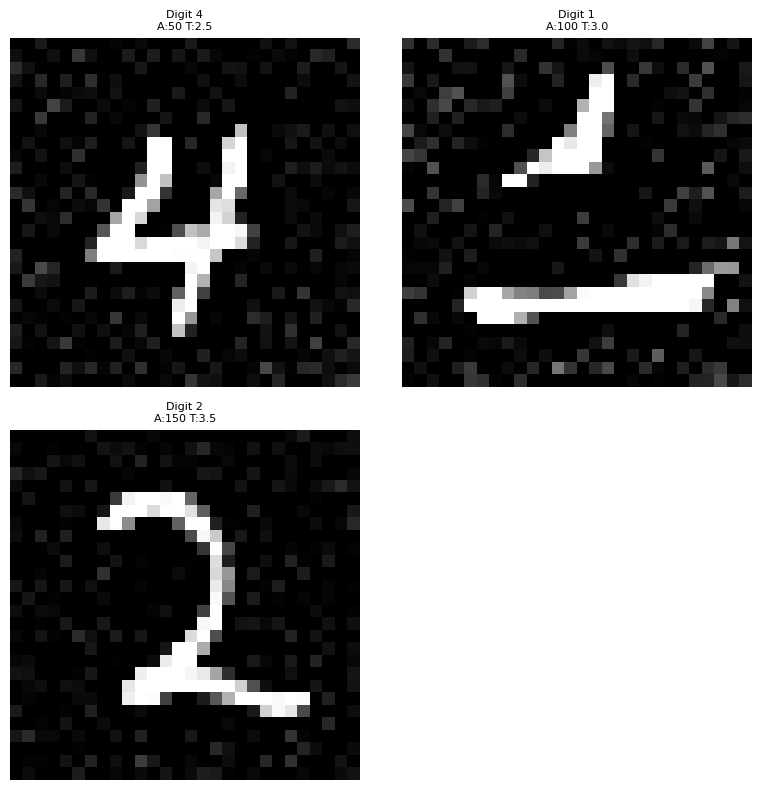

tensor([[[[-0.1251, -0.0942,  0.1022,  ..., -0.2155, -0.2335,  0.1685],
          [ 0.0573, -0.3329, -0.0372,  ...,  0.1266, -0.0391, -0.0642],
          [ 0.1781,  0.0620, -0.0078,  ..., -0.1517,  0.0837, -0.0455],
          ...,
          [-0.1261, -0.1355, -0.0226,  ...,  0.0654,  0.1264,  0.0815],
          [ 0.1569, -0.3280, -0.1781,  ...,  0.0559, -0.1403,  0.0424],
          [-0.0666, -0.1669,  0.1012,  ...,  0.0650,  0.1668,  0.2287]]],


        [[[ 0.1843, -0.1470,  0.1714,  ..., -0.3416,  0.0837,  0.0065],
          [-0.0665, -0.0620, -0.3836,  ...,  0.0172, -0.1408, -0.1509],
          [ 0.0765, -0.0394, -0.0674,  ..., -0.0565, -0.2020,  0.1001],
          ...,
          [ 0.1141, -0.1312,  0.0592,  ..., -0.0935, -0.1994, -0.2367],
          [-0.1636,  0.0657, -0.0671,  ...,  0.2212, -0.0097, -0.1191],
          [ 0.0120, -0.0743,  0.0623,  ...,  0.2844,  0.0932,  0.1755]]],


        [[[-0.1214,  0.0018, -0.0196,  ..., -0.0591, -0.0634,  0.0531],
          [ 0.0326, -0.017

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sample(model, rf, num_samples, cfg_scale, y=None, morpho=None, num_steps=50, device='cuda'):
    """Generate samples using the trained FiLM flow matching model

    Args:
        model: Trained MiniUnetFiLM model
        rf: RectifiedFlow instance
        num_samples: Number of samples to generate
        cfg_scale: Classifier-free guidance scale
        y: Labels for conditioning (optional)
        morpho: Morphometric features for conditioning (optional)
        num_steps: Number of integration steps
        device: Device to run on
    """
    # Handle label conditioning
    if y is not None:
        assert len(y.shape) == 1, 'y must be 1D tensor'
        if y.shape[0] == 1:
            y = y.repeat(num_samples)
        elif y.shape[0] != num_samples:
            # If different number of labels, repeat the first one
            y = y[0].repeat(num_samples)
        y = y.to(device)

    # Handle morphometric conditioning
    if morpho is not None:
        morpho_device = {}
        for k, v in morpho.items():
            if v.shape[0] == 1:
                morpho_device[k] = v.repeat(num_samples).to(device)
            elif v.shape[0] != num_samples:
                # If different number of morpho values, repeat to match num_samples
                morpho_device[k] = v[:num_samples].to(device) if v.shape[0] >= num_samples else v[0].repeat(num_samples).to(device)
            else:
                morpho_device[k] = v.to(device)
        morpho = morpho_device

    model.eval()
    with torch.no_grad():
        dt = 1.0 / num_steps
        # Start from noise
        x_t = torch.randn(num_samples, 1, 28, 28, device=device)

        # Integrate the flow from t=0 to t=1
        for i in range(num_steps):
            t = torch.full((num_samples,), i * dt, device=device)

            # Unconditional prediction (no labels, no morphometrics)
            v_pred_uncon = model(x_t, t, y=None, morpho=None)

            # Conditional prediction with both labels and morphometrics
            v_pred_con = model(x_t, t, y=y, morpho=None)

            # Classifier-free guidance
            v_pred = v_pred_uncon + cfg_scale * (v_pred_con - v_pred_uncon)
            x_t = rf.euler(x_t, v_pred, dt)

        return x_t

def sample_with_varied_conditioning(model, rf, num_samples, cfg_scale, y=None, morpho=None, num_steps=50, device='cuda'):
    """Generate samples with more flexible conditioning options for FiLM model
    
    This function allows for different combinations of label and morphometric conditioning
    """
    model.eval()
    with torch.no_grad():
        dt = 1.0 / num_steps
        x_t = torch.randn(num_samples, 1, 28, 28, device=device)

        # Handle conditioning inputs
        if y is not None:
            y = y.to(device)
            if len(y.shape) == 0:  # Single value
                y = y.repeat(num_samples)
            elif y.shape[0] != num_samples:
                y = y[:num_samples] if y.shape[0] >= num_samples else y[0].repeat(num_samples)

        if morpho is not None:
            morpho_processed = {}
            for k, v in morpho.items():
                v = v.to(device)
                if v.shape[0] != num_samples:
                    if v.shape[0] == 1:
                        morpho_processed[k] = v.repeat(num_samples)
                    else:
                        morpho_processed[k] = v[:num_samples] if v.shape[0] >= num_samples else v[0].repeat(num_samples)
                else:
                    morpho_processed[k] = v
            morpho = morpho_processed

        # Integration loop
        for i in range(num_steps):
            t = torch.full((num_samples,), i * dt, device=device)

            # Get unconditional and conditional predictions
            v_pred_uncon = model(x_t, t, y=None, morpho=None)
            v_pred_con = model(x_t, t, y=y, morpho=morpho)

            # Apply classifier-free guidance
            v_pred = v_pred_uncon + cfg_scale * (v_pred_con - v_pred_uncon)
            x_t = rf.euler(x_t, v_pred, dt)

        return x_t

def visualize_samples(samples, num_display=16, figsize=(8, 8), titles=None):
    """Enhanced visualization with optional titles"""
    samples = samples.cpu().numpy()
    samples = np.clip(samples, 0, 1)

    grid_size = int(np.sqrt(num_display))
    if grid_size * grid_size < num_display:
        grid_size += 1

    fig, axes = plt.subplots(grid_size, grid_size, figsize=figsize)
    axes = axes.flatten() if num_display > 1 else [axes]

    for i in range(grid_size * grid_size):
        if i < len(samples) and i < num_display:
            img = samples[i, 0]
            axes[i].imshow(img, cmap='gray')
            axes[i].axis('off')
            if titles and i < len(titles):
                axes[i].set_title(titles[i], fontsize=8)
        else:
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

def generate_samples_with_ema(ema_model, rf, cfg_scale, y=None, morpho=None, num_samples=16, num_steps=100, device='cuda'):
    """Updated generation function for FiLM EMA model"""
    print(f"Generating {num_samples} samples using FiLM EMA model...")
    print(f"Using {num_steps} integration steps for high quality...")
    
    if y is not None:
        print(f"Label conditioning: {y}")
    if morpho is not None:
        print(f"Morphometric conditioning:")
        for k, v in morpho.items():
            print(f"  {k}: {v}")

    # Generate samples using the updated sample function
    samples = sample(ema_model, rf, num_samples=num_samples, cfg_scale=cfg_scale, 
                    y=y, morpho=morpho, num_steps=num_steps, device=device)

    print("Visualizing samples...")
    
    # Create titles for visualization
    titles = []
    if y is not None and morpho is not None:
        for i in range(min(num_samples, 16)):
            y_val = y[i] if i < len(y) else y[0]
            area_val = morpho['area'][i] if i < len(morpho['area']) else morpho['area'][0]
            thick_val = morpho['thickness'][i] if i < len(morpho['thickness']) else morpho['thickness'][0]
            titles.append(f"Digit {y_val.item():.0f}\nA:{area_val:.0f} T:{thick_val:.1f}")
    
    visualize_samples(samples, num_samples, titles=titles)
    return samples
def load_ema_model(checkpoint_path, device='cuda'):
    """Properly load EMA model from checkpoint with memory efficiency"""
    # Create the SAME architecture as used in training
    # Based on the error, the saved model has attention=True and num_res_blocks=2
    model = ImprovedDeepMiniUnetFiLM(
        base_channels=32,          # SAME as training
        condition_dim=64,          # SAME as training  
        use_morphometrics=True,   # SAME as training
        num_res_blocks=2,          # CORRECTED: Must match training (was 1, should be 2)
        use_attention=True,        # CORRECTED: Must match training (was False, should be True)
        dropout=0.1                
    ).to(device)
    
    # Load the checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Create EMA wrapper and load the EMA state dict
    ema = EMA(model, decay=0.999, device=device)
    ema.load_state_dict(checkpoint['ema_state_dict'])
    
    # Return the EMA model
    return ema.module.to(device)

# Test the updated sampling with better morphometric conditioning
def test_morphometric_conditioning(ema_model, rf, device='cuda'):
    """Test function to demonstrate morphometric conditioning capabilities"""
    print("Testing morphometric conditioning with FiLM model...")
    
    # Test 1: Same digit, different areas
    print("\n1. Testing area variation (digit 7):")
    morpho_area_test = {
        'area': torch.tensor([50.0, 100.0, 150.0]),
        'thickness': torch.tensor([2.5, 3.0, 3.5]),
        'width': torch.tensor([12.0, 14.0, 16.0]),
        'height': torch.tensor([18.0, 20.0, 22.0])
    }
    samples_area = generate_samples_with_ema(
        ema_model, rf, cfg_scale=7,
        y=torch.tensor([4,,2]),
        morpho=morpho_area_test,
        num_samples=3, num_steps=100, device=device
    )
    
    return samples_area

sample_model=load_ema_model('morpho_ckpt_15.pth', device=device)
sample_model.eval()
test_morphometric_conditioning(sample_model, rf, device=device)

# print("\nGenerating samples with improved morphometric conditioning...")
# morpho_condition = {
#     'area': torch.tensor([80.0, 120.0, 160.0, 200.0]),     # Small to large areas
#     'thickness': torch.tensor([1.5, 2.0, 2.5, 3.0]),       # Thin to thick
#     'length': torch.tensor([30.0, 35.0, 40.0, 45.0])       # Short to long
# }

# samples_morpho = generate_samples_with_ema(
#     sampling_model, rf,
#     y=torch.tensor([7, 7, 7, 7]),  # All digit "7" but with different morphometrics
#     morpho=morpho_condition,
#     cfg_scale=7,
#     num_samples=4,
#     num_steps=100,
#     device=device
# )

# print("Sample generation completed!")

Model loaded successfully!
GPU Memory - Allocated: 0.36GB, Cached: 0.56GB
RAM Usage: 21.0% (6.07GB/31.25GB)


/tmp/ipykernel_7736/4125235468.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y=torch.tensor(torch.arange(0,10,1)),  # Mixed digits


Sample generation successful!


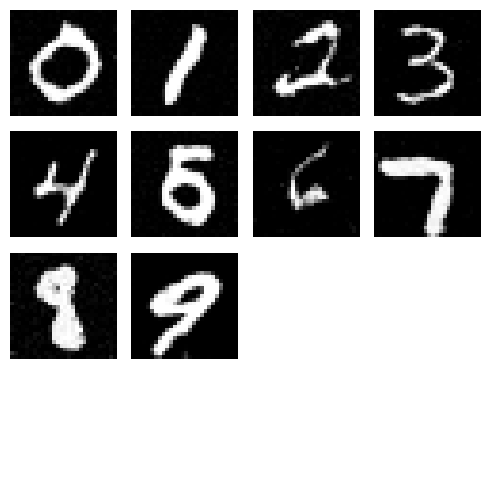

In [ ]:
# Memory-efficient model loading and sampling
def load_ema_model(checkpoint_path, device='cuda'):
    """Properly load EMA model from checkpoint with memory efficiency"""
    # Create the SAME architecture as used in training
    # Based on the error, the saved model has attention=True and num_res_blocks=2
    model = DeepMiniUnetFiLM(
        base_channels=32,          # SAME as training
        condition_dim=64,          # SAME as training  
        use_morphometrics=False,   # SAME as training
        num_res_blocks=2,          # CORRECTED: Must match training (was 1, should be 2)
        use_attention=True,        # CORRECTED: Must match training (was False, should be True)
        dropout=0.1                
    ).to(device)
    
    # Load the checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Create EMA wrapper and load the EMA state dict
    ema = EMA(model, decay=0.999, device=device)
    ema.load_state_dict(checkpoint['ema_state_dict'])
    
    # Return the EMA model
    return ema.module.to(device)

# Clear memory before loading
clear_memory()

try:
    # Try to load the latest checkpoint
    sampling_model = load_ema_model('morpho_ckpt_5.pth', device=device)
    sampling_model.eval()
    rf = RectifiedFlow()
    
    print("Model loaded successfully!")
    get_memory_info()
    
    # Generate a small batch of samples to test
    with torch.no_grad():
        samples = sample(
            sampling_model,
            rf,
            num_samples=10,  # Start with small number
            cfg_scale=1.5,  # Lower guidance scale
            y=torch.tensor(torch.arange(0,10,1)),  # Mixed digits
            morpho=None,
            num_steps=25,   # Fewer steps for memory efficiency
            device=device
        )
        
    print("Sample generation successful!")
    visualize_samples(samples, num_display=10, figsize=(5, 5))
    
except FileNotFoundError:
    print("No checkpoint found yet. Please run training first.")
except RuntimeError as e:
    if "out of memory" in str(e):
        print("OOM during sampling. Try reducing num_samples or num_steps.")
        clear_memory()
    else:
        print(f"Error loading model: {e}")
        print("\nTip: The model architecture must match exactly what was used during training.")
        print("Check the training configuration in cell 14 for the correct parameters.")
        raise e